Diabetes Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv(r"C:\Users\laksh\Downloads\diabetes_prediction_dataset.csv\diabetes_prediction_dataset.csv")
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
df.shape

(100000, 9)

In [4]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [5]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [6]:
df = df.drop(columns=["bmi"])

In [7]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,6.6,140,0
1,Female,54.0,0,0,No Info,6.6,80,0
2,Male,28.0,0,0,never,5.7,158,0
3,Female,36.0,0,0,current,5.0,155,0
4,Male,76.0,1,1,current,4.8,155,0


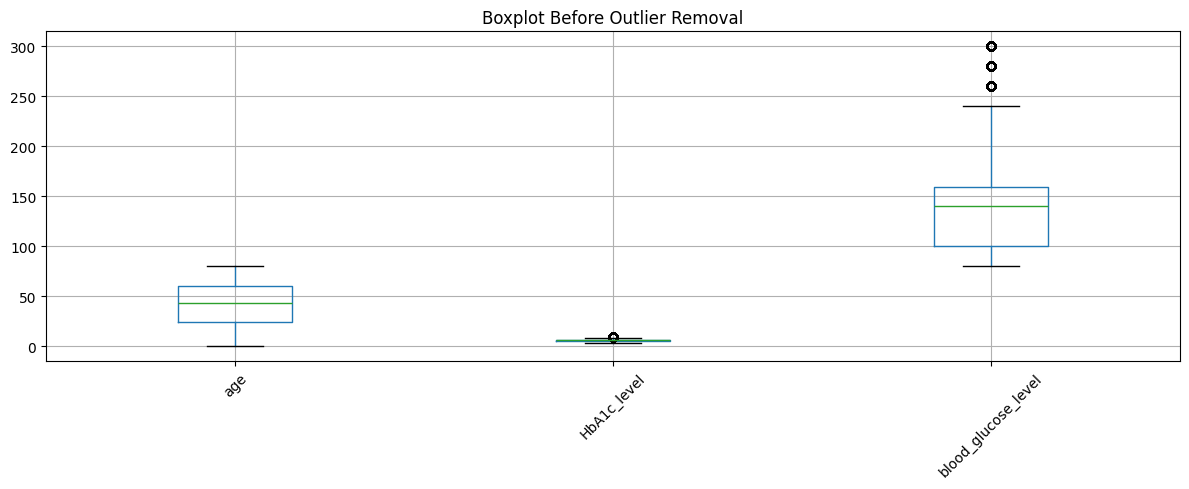

Rounds needed    : 1
Rows after removal: 96957


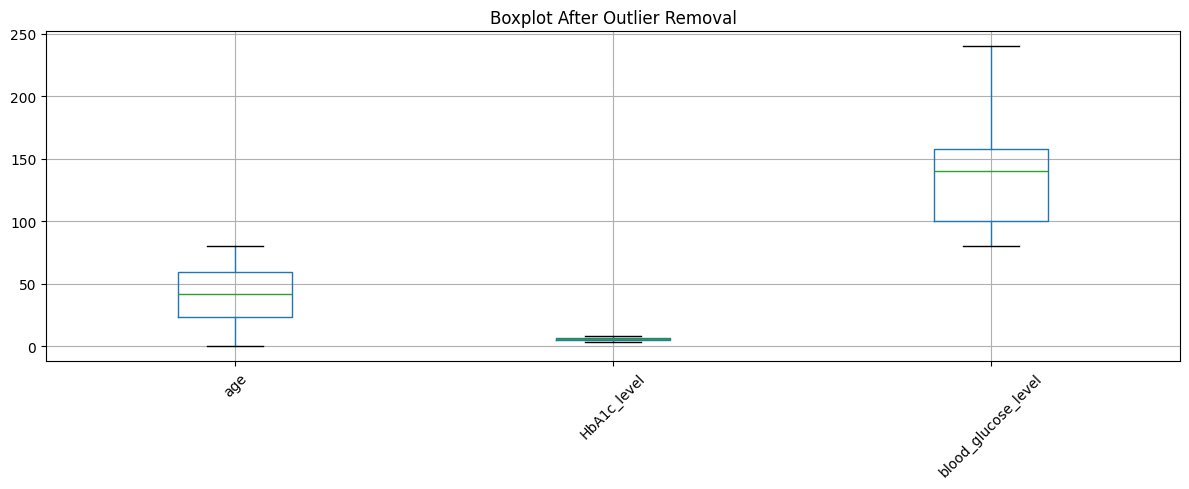

In [8]:
# Before Outlier Removal
numeric_cols = ["age", "HbA1c_level", "blood_glucose_level"]

df[numeric_cols].boxplot(figsize=(12, 5))
plt.xticks(rotation=45)
plt.title("Boxplot Before Outlier Removal")
plt.tight_layout()
plt.show()

# Remove outliers using IQR loop
rounds = 0
while True:
    total_outliers = set()
    for col in numeric_cols:
        Q1  = df[col].quantile(0.25)
        Q3  = df[col].quantile(0.75)
        IQR = Q3 - Q1
        outlier_index = df[
            (df[col] < Q1 - 1.5 * IQR) |
            (df[col] > Q3 + 1.5 * IQR)
        ].index
        total_outliers.update(outlier_index)
    if len(total_outliers) == 0:
        break
    df = df.drop(index=total_outliers).reset_index(drop=True)
    rounds += 1

print("Rounds needed    :", rounds)
print("Rows after removal:", len(df))

# After Outlier Removal
df[numeric_cols].boxplot(figsize=(12, 5))
plt.xticks(rotation=45)
plt.title("Boxplot After Outlier Removal")
plt.tight_layout()
plt.show()

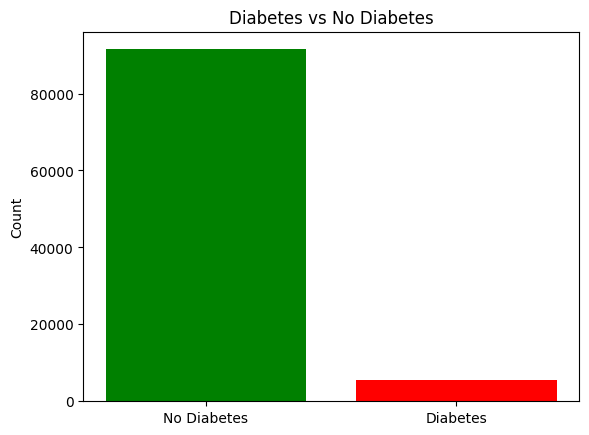

In [9]:
# Diabetes count
diabetes_counts = df["diabetes"].value_counts()
plt.bar(["No Diabetes", "Diabetes"], diabetes_counts.values, color=["green", "red"])
plt.title("Diabetes vs No Diabetes"); plt.ylabel("Count"); plt.show()

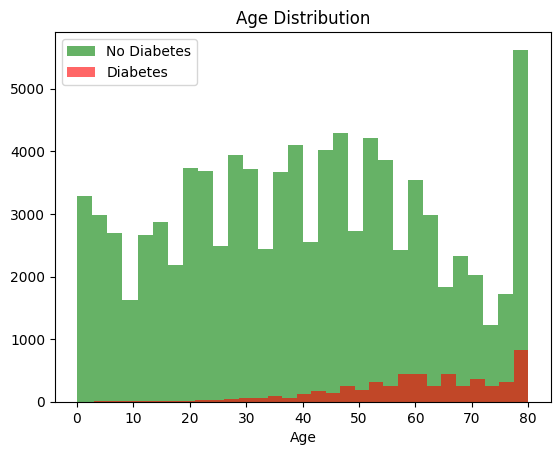

In [10]:
# Age distribution
plt.hist(df[df["diabetes"]==0]["age"], bins=30, alpha=0.6, color="green", label="No Diabetes")
plt.hist(df[df["diabetes"]==1]["age"], bins=30, alpha=0.6, color="red", label="Diabetes")
plt.title("Age Distribution"); plt.xlabel("Age"); plt.legend(); plt.show()

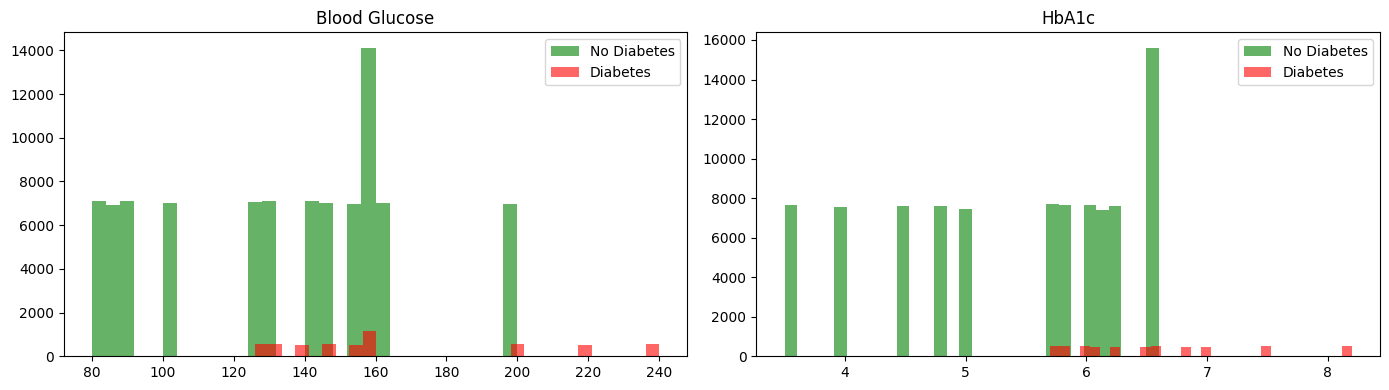

In [11]:
# Blood Glucose & HbA1c
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in zip(axes, ["blood_glucose_level", "HbA1c_level"], ["Blood Glucose", "HbA1c"]):
    ax.hist(df[df["diabetes"]==0][col], bins=30, alpha=0.6, color="green", label="No Diabetes")
    ax.hist(df[df["diabetes"]==1][col], bins=30, alpha=0.6, color="red", label="Diabetes")
    ax.set_title(title); ax.legend()
plt.tight_layout(); plt.show()

In [12]:
le = LabelEncoder()
df["gender"] = le.fit_transform(df["gender"])
df["smoking_history"] = le.fit_transform(df["smoking_history"])

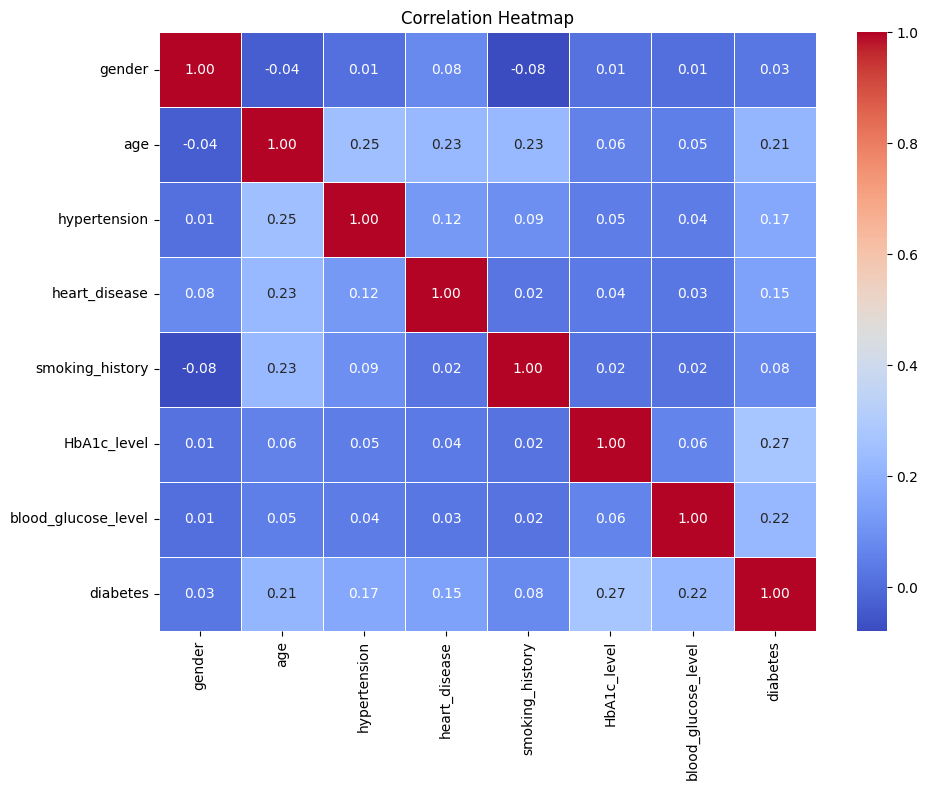

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap"); plt.tight_layout(); plt.show()

In [14]:
X = df.drop(columns=["diabetes"])
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Models

In [15]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr)*100)

Logistic Regression: 95.75082508250826


In [16]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN:", accuracy_score(y_test, y_pred_knn)*100)

KNN: 96.35416666666666


In [17]:
from sklearn.svm import SVC

svc = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)
print("SVC:", accuracy_score(y_test, y_pred_svc)*100)

SVC: 96.31291254125412


In [18]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)
print("Naive Bayes:", accuracy_score(y_test, y_pred_gnb)*100)

Naive Bayes: 90.59921617161716


In [19]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion='entropy', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree:", accuracy_score(y_test, y_pred_dt)*100)

Decision Tree: 95.54971122112211


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest:", accuracy_score(y_test, y_pred_rf)*100)

Random Forest: 96.40057755775577


In [21]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=50, learning_rate=0.1, random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)
print("AdaBoost:", accuracy_score(y_test, y_pred_ada)*100)

AdaBoost: 95.98287953795379


In [22]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print("XGBoost:", accuracy_score(y_test, y_pred_xgb)*100)

XGBoost: 97.04517326732673


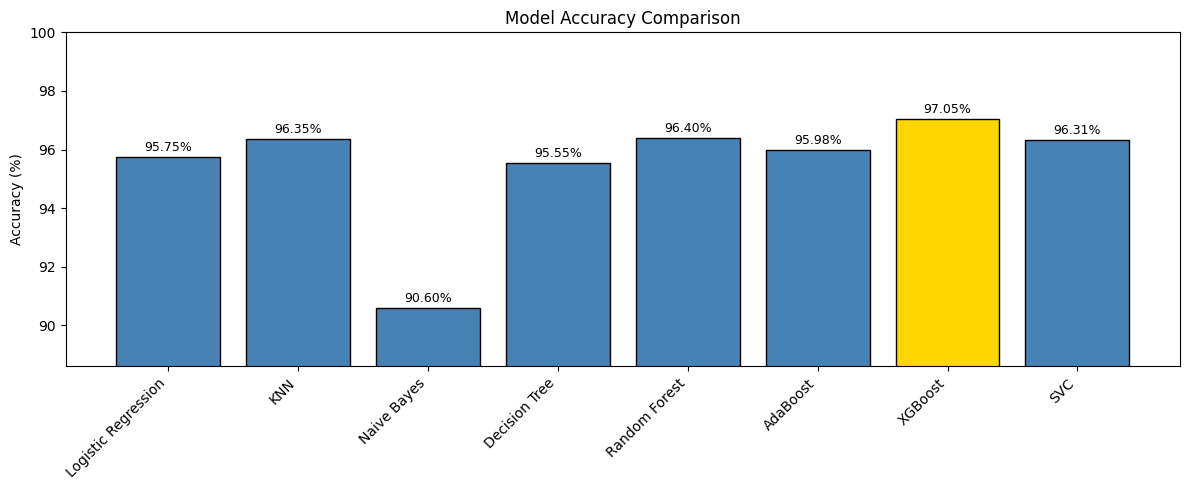

In [23]:
models = {
    "Logistic Regression": y_pred_lr,
    "KNN":                 y_pred_knn,
    "Naive Bayes":         y_pred_gnb,
    "Decision Tree":       y_pred_dt,
    "Random Forest":       y_pred_rf,
    "AdaBoost":            y_pred_ada,
    "XGBoost":             y_pred_xgb,
    "SVC":                 y_pred_svc,
}

names = list(models.keys())
accs  = [accuracy_score(y_test, p)*100 for p in models.values()]
best  = names[accs.index(max(accs))]

plt.figure(figsize=(12, 5))
bars = plt.bar(names, accs, color=["gold" if n==best else "steelblue" for n in names], edgecolor="black")
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.1,
             f"{acc:.2f}%", ha='center', va='bottom', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.ylim(min(accs)-2, 100)
plt.ylabel("Accuracy (%)"); plt.title("Model Accuracy Comparison")
plt.tight_layout(); plt.show()

**Conclusion**

In this project, we predicted diabetes using a real-world dataset. After cleaning the data, removing outliers, and encoding categorical variables, we trained and compared 8 machine learning models.
Among all the models, XGBoost achieved the highest accuracy, making it the best performing model for this dataset.
Key factors found to influence diabetes prediction were blood glucose level, HbA1c level, and age, as seen from the correlation heatmap.
Overall, XGBoost proves to be an effective model for early diabetes detection, which can help in timely medical diagnosis and treatment.